# Agent ReAct avec LangGraph 🦜🕸️
Un agent qui **raisonne** puis **agit** (appelle des outils) en boucle, construit à la main avec LangGraph.


In [34]:
%pip install python-dotenv

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importations


In [ ]:
from dotenv import load_dotenv
import os
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
import requests
load_dotenv(force=True)

## 2. Création des outils (tools)

In [26]:
@tool
def triple(num: float) -> float:
    """Triple un nombre (le multiplie par 3)."""
    return 3 * float(num)

@tool
def meteo(ville: str) -> str:
    """Donne la meteo actuelle d'une ville (temperature et description)."""
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {"q": ville, "appid": "aaa721629619b4371003eb3753489257", "units": "metric", "lang": "fr"}
    data = requests.get(url, params=params).json()
    return f"A {ville}, il fait {data['main']['temp']}C, {data['weather'][0]['description']}."

tools = [triple, meteo]

## 3. Le modèle (avec bind_tools)

In [ ]:
#llm = ChatOllama(model="qwen3:4b").bind_tools(tools) #local model

In [ ]:

llm = ChatOllama(
    model="gemma4:31b",          # a cloud model, not qwen3:4b
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": "Bearer " + os.environ["OLLAMA_API_KEY"]}},
).bind_tools(tools)

## 4. Les Nodes (les boîtes du graphe)

In [28]:
# Le message système = les instructions de l'agent
SYSTEM_MESSAGE = (
    "Tu es un assistant qui DOIT utiliser les outils disponibles pour repondre. "
    "Pour toute question sur la meteo, utilise TOUJOURS l'outil 'meteo'. "
    "Pour tripler un nombre, utilise l'outil 'triple'. "
    "N'invente jamais de reponse : appelle les outils."
)
# NODE 1 : agent_reason -> l'agent réfléchit (appelle le LLM)
def agent_reason(state: MessagesState) -> MessagesState:
    response = llm.invoke(
        [{"role": "system", "content": SYSTEM_MESSAGE}, *state["messages"]]
    )
    return {"messages": [response]}

# NODE 2 : act -> exécute les tools que l'agent a demandés
act = ToolNode(tools)

## 5. Le graphe : nodes, condition et boucle

In [29]:
AGENT_REASON = "reflexion"
ACT = "outils"

# LA CONDITION : que faire après que l'agent a réfléchi ?
def should_continue(state: MessagesState) -> str:
    last_message = state["messages"][-1]
    if not last_message.tool_calls:   # l'agent n'a demandé aucun tool
        return END                    # -> on termine
    return ACT                        # -> sinon on exécute les tools

# On construit le graphe
graph = StateGraph(MessagesState)

# On ajoute les 2 nodes
graph.add_node(AGENT_REASON, agent_reason)
graph.add_node(ACT, act)

# Le point de départ
graph.set_entry_point(AGENT_REASON)

# EDGE CONDITIONNEL : après agent_reason, on suit should_continue
graph.add_conditional_edges(
    AGENT_REASON,
    should_continue,
    {ACT: ACT, END: END},
)

# EDGE NORMAL : après act, on RETOURNE réfléchir  (= LA BOUCLE)
graph.add_edge(ACT, AGENT_REASON)

## 6. Compiler et tester


In [30]:
app = graph.compile()

In [31]:
resultat = app.invoke({
    "messages": [HumanMessage(content="Quelle est la meteo a Sfax ? Ensuite triple la temperature.")]
})

print(resultat["messages"][-1].content)

A Sfax, il fait 31.73°C, ciel dégagé. La température triplée est 95.19.


## 7. Visualiser le graphe

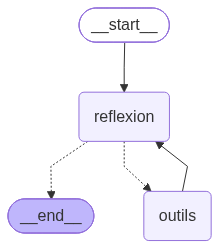

In [32]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))